---

## 📦 Cos'è CIFAR-10?

**CIFAR-10** è un **dataset di immagini** molto usato per imparare e testare algoritmi di **intelligenza artificiale**, in particolare per il **riconoscimento automatico di oggetti**.

---

### 🖼️ Caratteristiche principali:

* Contiene **60.000 immagini** a colori.
* Ogni immagine è molto piccola: **32×32 pixel**, con 3 canali (RGB).
* Le immagini sono divise in **10 categorie**.

---

### 🔟 Le 10 classi di CIFAR-10:

1. Aereo
2. Automobile
3. Uccello
4. Gatto
5. Cervo
6. Cane
7. Rana
8. Cavallo
9. Nave
10. Camion

---

### 📚 A cosa serve?

Viene usato per:

* **Allenare reti neurali** a riconoscere immagini.
* **Valutare modelli** di deep learning (come le CNN).
* Fare esperimenti sull'**intelligenza artificiale visiva**.

---

### 🧠 Perché è utile nella didattica?

* Le immagini sono piccole → adatte a esercizi veloci su Google Colab.
* Le classi sono semplici e concrete → stimolano l’interesse.
* È ottimo per **capire come ragiona un’IA** nel riconoscere il mondo.

---

### Caricamento librerie e dataset

In [3]:
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

# Caricamento dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()




170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step


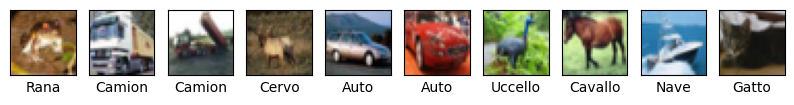

In [4]:
# Classi
class_names = ['Aereo', 'Auto', 'Uccello', 'Gatto', 'Cervo', 'Cane', 'Rana', 'Cavallo', 'Nave', 'Camion']

# Mostra alcune immagini le prime 10
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.show()

## Pre-processing di normalizzazione delle immagini

In [5]:
# Normalizzazione immagini
x_train = x_train / 255.0
x_test = x_test / 255.0

## Costruzione della CNN

In [6]:
from tensorflow.keras import models, layers

model = models.Sequential()
model.add(layers.Input(shape=(32, 32, 3)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))

model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))


---

### 🧱 Struttura generale:

```python
model = models.Sequential()
```

👉 Crea un modello “a strati” (**uno sopra l’altro**), dove ogni strato passa le informazioni al successivo.

---

### 📥 Input layer:

```python
model.add(layers.Input(shape=(32, 32, 3)))
```

👉 Dice al modello che ogni immagine ha **32×32 pixel e 3 canali di colore (RGB)**. È lo **strato di ingresso**.

---

### 🔍 Primo strato convoluzionale:

```python
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
```

👉 Applica **32 filtri 3×3** per cercare **forme semplici** (es. bordi, angoli) nell’immagine.
L’**attivazione ReLU** serve per introdurre non-linearità (cioè: permette alla rete di “capire” cose più complesse).





Significa:

* 32 filtri
* ciascuno di dimensione 3×3
* applicati scorrendo sull’immagine
* con attivazione ReLU

Vediamo cosa vuol dire davvero.

---

# 🧩 1️⃣ Cos’è un filtro 3×3?

Immagina un’immagine come una matrice di numeri (pixel).

Un filtro 3×3 è una piccola matrice di pesi:

$$
\begin{bmatrix}
w_{11} & w_{12} & w_{13} \\
w_{21} & w_{22} & w_{23} \\
w_{31} & w_{32} & w_{33}
\end{bmatrix}
$$

Questo filtro:

1. Si appoggia su un quadratino 3×3 dell’immagine.
2. Moltiplica pixel × peso.
3. Somma tutto.
4. Produce un numero.

Poi si sposta di un pixel e ripete.

È una **scansione locale**.

---

# 🎯 2️⃣ Perché “trova bordi”?

Se i pesi del filtro si organizzano così:

$$
\begin{bmatrix}
-1 & -1 & -1 \\
0 & 0 & 0 \\
1 & 1 & 1
\end{bmatrix}
$$

Questo filtro risponde fortemente quando c’è un cambiamento verticale → cioè un bordo.

Ma attenzione:

👉 Tu NON imposti questi pesi.
👉 La rete li impara durante il training.

All’inizio sono casuali.
Poi, tramite backpropagation, si specializzano.

---

# 🎨 3️⃣ Perché 32 filtri?

Ogni filtro impara qualcosa di diverso.

Con 32 filtri ottieni:

* 32 mappe di attivazione
* ognuna evidenzia un tipo diverso di pattern

Analogia:

Immagina 32 esperti che guardano l’immagine:

* uno cerca linee orizzontali
* uno linee verticali
* uno curve
* uno texture
* uno angoli
* uno contrasti
* ecc.

Ogni filtro produce una “versione trasformata” dell’immagine.

---

# 📦 4️⃣ Cosa esce dal layer?

Se l’immagine è 28×28×1 (MNIST), l’output sarà:

28×28×32 (circa, dipende dal padding)

Non è più un’immagine singola.

È un **volume 3D**:

* altezza
* larghezza
* 32 canali

Ogni canale è una feature map.

---

# ⚡ 5️⃣ Perché serve ReLU?

La convoluzione è un’operazione lineare.

Se non metti attivazione, la rete diventa una grande trasformazione lineare → limitata.

ReLU fa:

$$
f(x) = \max(0, x)
$$

Cosa significa intuitivamente?

* elimina valori negativi
* mantiene solo attivazioni forti
* introduce non linearità

Senza non-linearità, la rete non può modellare strutture complesse.

---

# 🧠 Intuizione completa

Conv2D fa questo:

1. Guarda piccole porzioni locali.
2. Costruisce rilevatori di pattern.
3. Produce mappe che evidenziano quei pattern.
4. ReLU mantiene solo le attivazioni “interessanti”.

I layer successivi combineranno:

* bordi → forme
* forme → parti di oggetti
* parti → oggetti completi

È una costruzione gerarchica.

---

# 🎼 Analogia musicale

Immagina una canzone.

* Il primo layer rileva note semplici.
* Il secondo combina note in accordi.
* Il terzo combina accordi in melodie.

La CNN fa la stessa cosa con le immagini.

---

# 📌 Riassunto essenziale

```python
Conv2D(32, (3,3))
```

= 32 piccoli scanner che imparano a riconoscere pattern locali 3×3.

```python
activation='relu'
```

= mantiene solo segnali significativi e rende la rete capace di modellare strutture non lineari.

---




### 🔽 Primo max pooling:

```python
model.add(layers.MaxPooling2D((2, 2)))
```

👉 Riduce la dimensione dell’immagine (fa una “sintesi” prendendo solo il massimo in ogni blocco 2×2) → così il modello è più veloce e si concentra sulle **informazioni più importanti**.

# 📦 1️⃣ Cos’è un blocco 2×2?

Significa che il layer prende **4 pixel alla volta**, organizzati così:

$$
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
$$

e restituisce **un solo valore**:

$$
\max(a, b, c, d)
$$

Questa operazione viene fatta su tutta la mappa delle feature.

---

# 🔎 2️⃣ Cosa succede geometricamente?

Immagina una feature map 6×6:

```
1 2 3 4 5 6
7 8 9 1 2 3
4 5 6 7 8 9
1 2 3 4 5 6
7 8 9 1 2 3
4 5 6 7 8 9
```

Con MaxPooling 2×2 (stride 2), la rete divide così:

```
[1 2] [3 4] [5 6]
[7 8] [9 1] [2 3]

[4 5] [6 7] [8 9]
[1 2] [3 4] [5 6]

[7 8] [9 1] [2 3]
[4 5] [6 7] [8 9]
```

Ogni blocco diventa un numero (il massimo).

Risultato: matrice 3×3.

```
[8] [9] [6]
[5] [7] [9]
[8] [9] [9]

```


👉 Dimensione dimezzata.

---

# 📐 3️⃣ Effetto sulle dimensioni

Se l’input è:

```
28 × 28 × 32
```

Dopo `MaxPooling2D((2,2))` diventa:

```
14 × 14 × 32
```

* altezza dimezzata
* larghezza dimezzata
* numero di canali invariato

---

# 🎯 4️⃣ Perché prende il massimo?

Perché nelle feature map:

* valori alti = presenza forte di un pattern
* valori bassi = assenza

MaxPooling mantiene:

> “C’è questo pattern in questa zona?”

Non interessa esattamente dove nel blocco 2×2.

---

# 🧠 5️⃣ Intuizione profonda

Conv2D dice:

“Qui c’è un bordo.”

MaxPooling dice:

“Ok, in questa zona il bordo c’è sicuramente → lo tengo.”

È una forma di **sintesi spaziale**.

---

# 🎨 6️⃣ Analogia semplice

Immagina una mappa di calore.

Il pooling fa questo:

* divide la mappa in quadratini
* in ogni quadratino prende il punto più caldo

Così conserva solo le attivazioni più forti.

---

# 🚀 7️⃣ Perché è utile?

### 1) Riduce dimensione

Meno pixel → meno calcoli → rete più veloce.

### 2) Riduce overfitting

Meno parametri nei layer successivi.

---

# 📌 Differenza con convoluzione

| Conv2D             | MaxPooling        |
| ------------------ | ----------------- |
| Impara pesi        | Non ha pesi       |
| Rileva pattern     | Riassume pattern  |
| Aumenta profondità | Riduce dimensioni |

---

# 🎯 Riassunto preciso

`MaxPooling2D((2,2))` significa:

> Suddividere ogni feature map in blocchi 2×2 e sostituire ogni blocco con il suo valore massimo, dimezzando larghezza e altezza.

---





---

### 🔍 Secondo strato convoluzionale:

```python
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
```

👉 Cerca **forme più complesse** usando 64 nuovi filtri → tipo occhi, ruote, musetti, ecc.

---

### 🔽 Secondo max pooling:

```python
model.add(layers.MaxPooling2D((2, 2)))
```

👉 Riduce ancora la dimensione, come prima, per **riassumere** meglio le informazioni.

---

### 🧩 Flatten:

```python
model.add(layers.Flatten())
```

👉 Trasforma il risultato 2D (matrice) in un **vettore 1D** → così può essere usato da uno strato “pieno” (dense).

---

### 🔌 Strato denso (nascosto):

```python
model.add(layers.Dense(64, activation='relu'))
```

👉 È un normale strato di neuroni: riceve tutti i dati e **impara combinazioni utili** per riconoscere oggetti.

---

### 🎯 Strato di output:

```python
model.add(layers.Dense(10, activation='softmax'))
```

👉 Ultimo strato: **10 neuroni**, uno per ogni **classe di CIFAR-10**.
L’attivazione **softmax** restituisce le probabilità: il neurone con il valore più alto indica **quale classe ha riconosciuto** il modello (es. gatto, cane, auto...).

---

### 📝 Riassunto visuale

- 📷 Immagine →
- 🔍 Filtri →
- 🔽 Sintesi (pooling) →
- 🔍 Altri filtri →
- 🔽 Ancora pooling →
- 📏 Appiattimento →
- 💡 Strato nascosto →
- 🎯 Classificazione finale

---



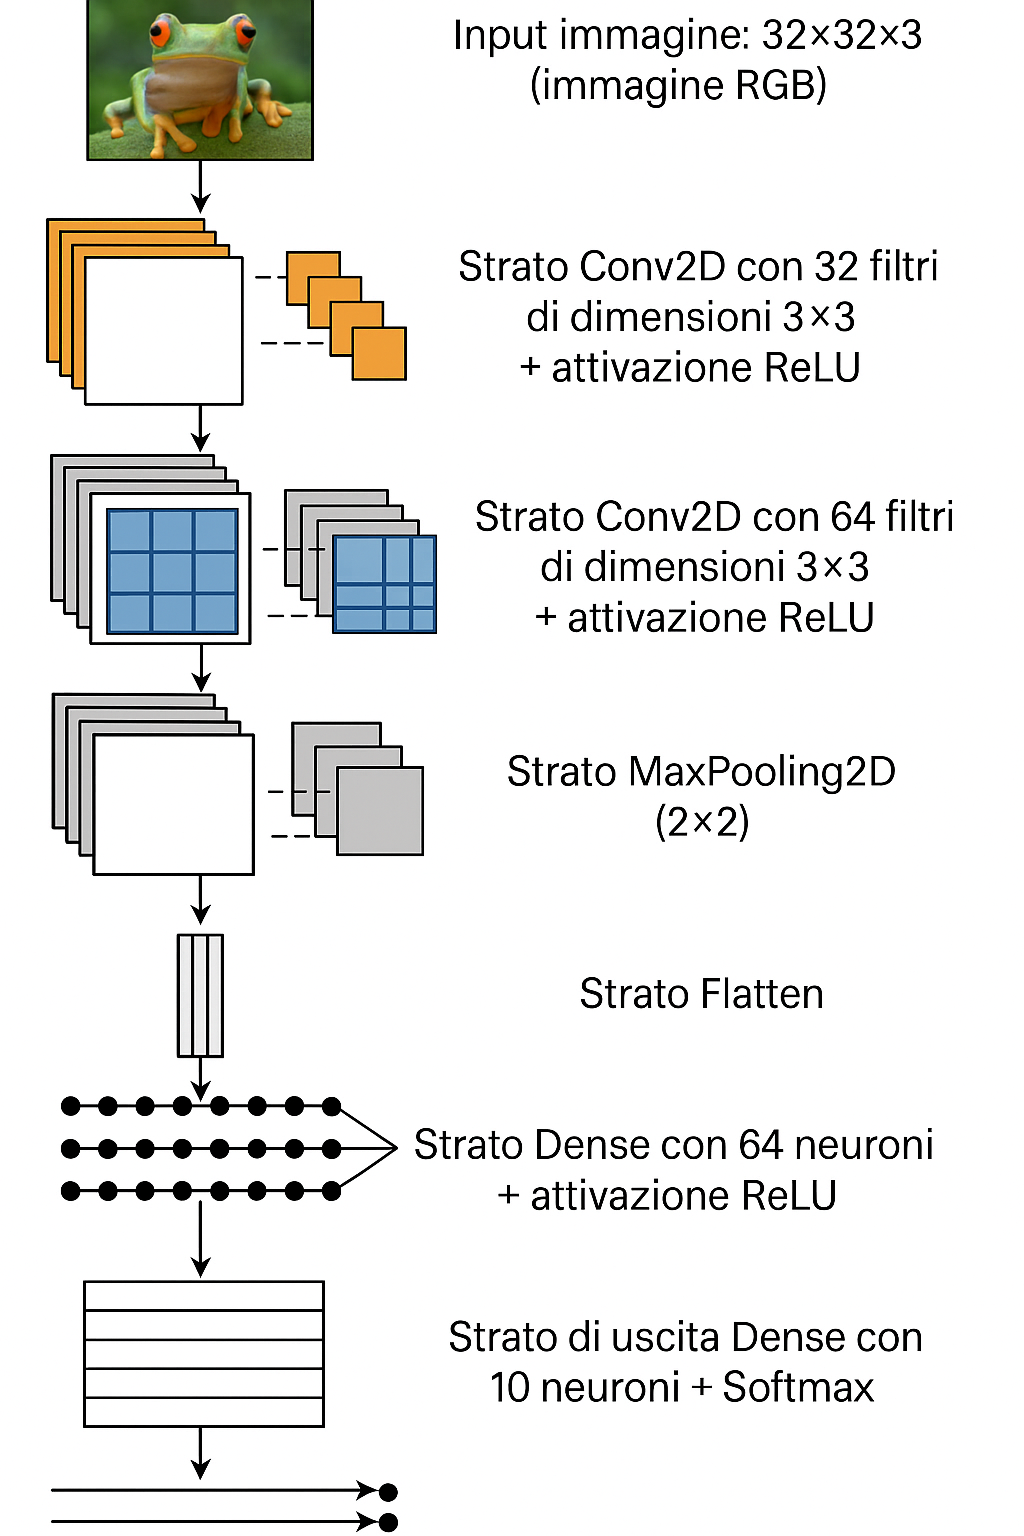

## Compilazione e training

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.3946 - loss: 1.6661 - val_accuracy: 0.5795 - val_loss: 1.1809
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6038 - loss: 1.1267 - val_accuracy: 0.6402 - val_loss: 1.0415
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6647 - loss: 0.9666 - val_accuracy: 0.6631 - val_loss: 0.9681
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6976 - loss: 0.8658 - val_accuracy: 0.6852 - val_loss: 0.9134
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7248 - loss: 0.7913 - val_accuracy: 0.6876 - val_loss: 0.9170
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7430 - loss: 0.7362 - val_accuracy: 0.6815 - val_loss: 0.9272
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7645 - loss: 0.6803 - val_accuracy: 0.6933 - val_loss: 0.9209
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7830 - loss: 0.6275 

## Valutazione e visualizzazione dei risultati

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print('\nAccuratezza su dati di test:', test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.7018 - loss: 0.9270

Accuratezza su dati di test: 0.7017999887466431



```
accuracy: 0.6992
loss:     0.9038
```

---

# 1️⃣ Accuracy = 0.6992

Significa:

> Il modello classifica correttamente il **69.92%** degli esempi.

Se il dataset è, ad esempio, CIFAR (10 classi):

* Baseline casuale = 10%
* 69% è molto meglio del caso
* Ma è ancora lontano da un modello “buono” (che sarebbe >97%)

---

## Cosa misura davvero l’accuracy?

$$
\text{Accuracy} = \frac{\text{predizioni corrette}}{\text{totale esempi}}
$$

È una misura discreta:

* o giusto
* o sbagliato

Non considera **quanto** il modello è sicuro.

---

# 2️⃣ Loss = 0.9038

La loss (`categorical_crossentropy` o `sparse_categorical_crossentropy`) misura:

> Quanto le probabilità predette si discostano dalla verità.

Non è una percentuale.

È una misura continua dell’errore probabilistico.

---

## Esempio intuitivo

Immagina che la classe vera sia "3".

Caso A:

```
[0.01, 0.02, 0.01, 0.90, 0.02, ...]
```

Predizione corretta e sicura → loss bassa.

Caso B:

```
[0.10, 0.12, 0.11, 0.25, 0.13, ...]
```

Predizione corretta ma poco sicura → loss più alta.

Caso C:

```
[0.30, 0.25, 0.20, 0.05, 0.10, ...]
```

Classe sbagliata → loss molto alta.

---

# 🔬 Relazione tra accuracy e loss

Possono divergere.

Esempio:

* Accuracy 70%
* Loss ancora alta (0.9)

Significa che:

> Il modello indovina abbastanza spesso, ma quando sbaglia è molto sicuro di sbagliare.

Oppure:

> Anche quando indovina, non è molto confidente.

---

# 📊 Interpretazione pratica del tuo caso

Accuracy ≈ 70%
Loss ≈ 0.90

Questo suggerisce:

* Il modello sta imparando.
* Non è ancora ben calibrato.
* Probabilmente è a poche epoche o la rete è semplice.


---

# 🎯 Regola empirica

Per classificazione a 10 classi:

* Loss ≈ 2.3 → modello casuale
* Loss ≈ 1.0 → apprendimento iniziale
* Loss < 0.3 → modello molto buono

---

# 📌 Differenza concettuale

| Accuracy                  | Loss                          |
| ------------------------- | ----------------------------- |
| misura decisione finale   | misura qualità probabilistica |
| discreta                  | continua                      |
| interpretabile facilmente | meno intuitiva                |

---

# 💡 In sintesi

Il tuo modello:

* Sta imparando
* Non è ancora maturo
* Ha ancora margine di miglioramento

---



## Proviamo a migliorare il modello
Noi usimo CNN “baseline” corretta, ma su CIFAR-10 è un po’ **corta** e tende a **perdere informazione** troppo presto. Le modifiche che ti danno più guadagno (a parità di semplicità) sono: **padding='same'**, **più conv per blocco**, **BatchNormalization**, **Dropout**, e **un Dense più capiente** (o GlobalAveragePooling).



### A) Metti `padding='same'` nelle conv

Con `valid` (default) riduci subito le dimensioni e perdi bordi/contesto. `same` mantiene 32×32 → feature più robuste.
Perfetto, lo spiego in modo semplice ma preciso.

Quando fai una convoluzione 3×3, il filtro deve “stare dentro” l’immagine.

Senza padding (`padding='valid'`, default):

* il filtro non può uscire dai bordi
* quindi i bordi vengono “tagliati”
* l’immagine si rimpicciolisce

---

# 📐 Esempio concreto

Immagine 32×32
Filtro 3×3

Senza padding:

[
32 - 3 + 1 = 30
]

Output → **30×30**

Hai perso un pixel per lato.

---

# 🎯 Cosa fa `padding='same'`

Aggiunge una cornice di zeri attorno all’immagine prima della convoluzione.

Così:

* il filtro può centrare anche i pixel di bordo
* la dimensione finale resta **uguale**

32×32 → 32×32

---

# 🧠 Visualizzazione intuitiva

Immagina l’immagine come un tavolo.

Senza padding:

* puoi appoggiare il filtro solo dove entra completamente.

Con padding:

* metti un “bordo di cuscinetti” attorno.
* il filtro può scorrere ovunque.

---

# 📦 Cosa significa “same”

Significa:

> L’output ha la **stessa dimensione spaziale** dell’input (se stride=1).

Non significa “stessa immagine”.
Significa stessa altezza e larghezza.

---

# 🔬 Perché è importante su CIFAR?

CIFAR è 32×32 → molto piccola.

Se fai:

Conv(3×3) → 30×30
MaxPool(2×2) → 15×15
Conv(3×3) → 13×13
MaxPool → 6×6

Perdi informazione molto rapidamente.

Con `same`:

32×32
→ 32×32
→ 16×16
→ 16×16
→ 8×8

Molto meglio.

---

# 🎯 Intuizione finale

`padding='same'` serve a:

* non perdere informazione ai bordi
* mantenere dimensioni stabili
* costruire reti più profonde senza “collassare” troppo presto

---

# 📌 Riassunto ultra sintetico

| padding | effetto             |
| ------- | ------------------- |
| valid   | riduce dimensioni   |
| same    | mantiene dimensioni |

---





### B) Fai **2 convoluzioni per blocco** prima del pooling

Schema tipico: Conv→Conv→Pool. La seconda conv combina pattern locali prima di comprimere.

# 🎯 Idea centrale

Fare:

```
Conv → Conv → Pool
```

invece di

```
Conv → Pool
```

permette alla rete di:

> Costruire pattern più complessi prima di ridurre la dimensione.

---

# 🧠 Analogia semplice: costruire una parola

Immagina di leggere una frase.

### Caso 1 — Conv → Pool

* Leggi una lettera
* Subito riassumi la frase

Troppo presto.

### Caso 2 — Conv → Conv → Pool

* Leggi lettere
* Costruisci sillabe
* Poi riassumi

Molto più informativo.

---

# 🔬 Cosa succede matematicamente

La prima convoluzione 3×3 vede un campo locale 3×3.

La seconda convoluzione 3×3, applicata sopra la prima, “vede” indirettamente un campo più grande.

Effetto cumulativo:

* 1 conv 3×3 → receptive field 3×3
* 2 conv 3×3 → receptive field 5×5 (effettivo)
* 3 conv 3×3 → 7×7

Quindi due conv consecutive:

> ampliano il contesto senza aumentare troppo i parametri.

---

# 📐 Perché è meglio farlo prima del pooling?

Il pooling:

* dimezza la risoluzione
* elimina dettagli fini

Se fai pooling troppo presto:

* perdi informazioni utili
* la seconda conv lavora su dati già “compressi”

Se fai due conv prima:

* elabori più finemente
* poi comprimi

È come rifinire un’immagine prima di ridurla.

---

# 🎨 Analogia visiva

Immagina un volto.

Prima conv:

* trova bordi

Seconda conv:

* combina bordi → forma di un occhio

Poi pooling:

* dice “in questa zona c’è un occhio”

Se fai pooling dopo la prima conv:

* potresti perdere dettagli necessari per riconoscere l’occhio.

---

# 📊 Effetto pratico su CIFAR

CIFAR è piccola (32×32).
Se fai pooling troppo presto:

32 → 16 → 8 → 4

Perdi capacità di distinguere dettagli sottili.

Due conv prima del pool:

* estrai più informazione
* poi riduci

Risultato → feature più robuste.

---

# ⚙️ Perché non aumenta troppo i parametri?

Due conv 3×3 hanno meno parametri di una conv 5×5.

Esempio:

* 1 conv 5×5 → 25 pesi
* 2 conv 3×3 → 9 + 9 = 18 pesi

Ma il receptive field è simile.

Quindi:

> Più profondità = più non-linearità = più potere espressivo

senza esplosione parametri.

---

# 📌 Sintesi semplice

Conv → Conv → Pool funziona meglio perché:

1. Costruisce pattern più complessi
2. Amplia il campo visivo effettivo
3. Introduce più non-linearità
4. Riduce informazione solo dopo averla elaborata

---

# 🧠 In una frase

È meglio “capire bene” l’immagine prima di comprimerla.





### C) Aggiungi **BatchNormalization**

Stabilizza e accelera training, spesso +2–5% accuracy.


# 🎯 Idea intuitiva

BatchNormalization serve a:

> Tenere “stabili” i numeri che passano dentro la rete durante il training.

È come mettere un regolatore automatico.

---

# 🧠 Analogia semplice — Classe di studenti

Immagina una classe.

Ogni studente (neurone) riceve numeri in ingresso.

Se questi numeri cambiano continuamente scala:

* un giorno tra 0 e 1
* un giorno tra -100 e 100
* un giorno tra 0 e 1000

lo studente fatica a imparare.

BatchNorm fa:

> “Ok, prima di passare i numeri allo studente, li rimetto sempre su una scala stabile.”

---

# 🔬 Cosa fa matematicamente

Per ogni batch:

1. Calcola la media
2. Calcola la deviazione standard
3. Trasforma i valori così:

$$
x_{norm} = \frac{x - \mu}{\sigma}
$$

Così:

* media ≈ 0
* varianza ≈ 1

Poi applica due parametri imparabili:

$$
y = \gamma x_{norm} + \beta
$$

Quindi la rete può comunque adattare scala e shift.

---

# 🎯 Perché aiuta?

### 1️⃣ Training più stabile

Evita che i valori “esplodano” o si schiaccino.

### 2️⃣ Permette learning rate più alto

Il gradiente è meno instabile.

### 3️⃣ Riduce overfitting (leggermente)

Introduce una piccola regolarizzazione.

### 4️⃣ Converge più velocemente

Spesso +2–5% accuracy su CNN.

---

# 🎨 Analogia visiva

Immagina di costruire una casa.

Ogni piano deve essere livellato prima di costruire sopra.

BatchNorm livella ogni piano.

---

# 📦 Dove si mette?

Tipicamente:

```
Conv → BatchNorm → ReLU
```

oppure nel tuo caso:

```
Conv → BN → Conv → BN → Pool
```

---

# 🚀 Perché su CIFAR ti ha fatto guadagnare 10%?

CIFAR è rumoroso e complesso.

Senza BN:

* le distribuzioni interne cambiano molto
* i layer profondi faticano

Con BN:

* la rete si stabilizza
* apprende feature migliori

---

# 📌 Riassunto ultra semplice

BatchNormalization:

> Rimette in ordine i numeri a ogni livello della rete per renderla più stabile e più facile da allenare.

---






### D) Aggiungi **Dropout**

Riduce overfitting (CIFAR-10 lo soffre facilmente).

# 🎯 Idea intuitiva

Dropout serve a:

> Evitare che la rete si “affezioni troppo” a neuroni specifici.

Durante il training, spegne casualmente una parte dei neuroni.

---

# 🧠 Analogia semplice — Squadra di studenti

Immagina una squadra che deve risolvere un problema.

Se lavorano sempre le stesse 3 persone:

* diventano bravissime
* gli altri non imparano
* la squadra diventa fragile

Dropout fa questo:

> Ogni volta, alcuni membri vengono “mandati a casa”.

Così:

* tutti devono imparare
* nessuno può dipendere da uno solo

---

# 🔬 Cosa fa tecnicamente

Se hai:

```python
layers.Dropout(0.5)
```

significa:

* durante il training
* il 50% dei neuroni viene messo a zero casualmente

Esempio:

```
[0.8, 0.3, 0.5, 0.9]
```

può diventare:

```
[0.8, 0, 0.5, 0]
```

Ad ogni batch cambia quali neuroni vengono spenti.

---

# ⚠️ Importante

Dropout funziona **solo durante il training**.

Durante il test:

* tutti i neuroni sono attivi
* ma i pesi sono scalati automaticamente

---

# 🎯 Perché aiuta?

Senza dropout:

* la rete può memorizzare il training set
* alcuni neuroni diventano “dominanti”
* overfitting

Con dropout:

* la rete deve distribuire l’informazione
* diventa più robusta
* generalizza meglio

---

# 📊 Intuizione matematica

Dropout è una forma di:

> regolarizzazione stocastica

È come allenare molte reti diverse e fare una media implicita.

---

# 🎨 Effetto pratico su CIFAR

Se hai un Dense(128):

* senza dropout → può memorizzare
* con Dropout(0.5) → più robusto

Spesso migliora validation accuracy di qualche punto percentuale.

---

# 📌 Dove metterlo?

Tipico schema CNN:

```
Conv → Conv → Pool → Dropout
Conv → Conv → Pool → Dropout
Flatten → Dense → Dropout → Output
```

---

# 📌 Riassunto in una frase

Dropout:

> Spegne neuroni a caso durante il training per rendere la rete meno dipendente da singole connessioni e più capace di generalizzare.

---






### E) Aumenta il classifier

`Dense(64)` è un collo di bottiglia. Metti `Dense(128).

Hai:

```python
Flatten()
Dense(64)
Dense(10)
```

e lo abbiamo cambiato in:

```python
Flatten()
Dense(128)
Dense(10)
```

# 🎯 1️⃣ Cosa fa il Dense nel classificatore?

La parte convoluzionale estrae feature spaziali.

Il Dense finale fa:

> combinare quelle feature per decidere la classe.

È il “decisore finale”.

---

# 🧠 Analogia semplice — Commissione giudicatrice

Le conv producono molte informazioni:

* c’è una ruota
* c’è una texture pelosa
* c’è una linea orizzontale
* ecc.

Il Dense è la commissione che decide:

“Se vedo ruote + finestrini → automobile”

Se la commissione ha solo 64 membri:

* può combinare meno relazioni

Se ne ha 128:

* può costruire decisioni più sofisticate

---

# 🔬 2️⃣ Collo di bottiglia informativo

Supponiamo che dopo il Flatten tu abbia:

```
8 × 8 × 64 = 4096 feature
```

Passare a:

```
Dense(64)
```

significa comprimere 4096 numeri in 64.

Compressione molto forte.

Potresti perdere informazioni utili.

Con:

```
Dense(128)
```

la compressione è meno drastica.

---

# 📊 3️⃣ Capacità espressiva

Numero parametri:

Con Dense(64):
$$
4096 × 64 ≈ 262k
$$

Con Dense(128):
$$
4096 × 128 ≈ 524k
$$

Hai raddoppiato la capacità di combinazione.

Su CIFAR questo può fare differenza.

---

# 🎯 4️⃣ Quando aiuta davvero?

Aiuta se:

* la parte convoluzionale ha già estratto buone feature
* il modello non è in forte overfitting
* il collo di bottiglia è nel classificatore

Non aiuta se:

* la CNN è troppo debole
* o il dataset è molto piccolo

---

# ⚠️ Attenzione

Più neuroni = più parametri = più rischio overfitting.

Ecco perché lo abbiamo accompagnato con:

```python
Dropout(0.5)
BatchNormalization()
```

---

# 🧠 Intuizione profonda

Conv layers:
→ apprendono rappresentazione

Dense layer:
→ apprende la frontiera decisionale nello spazio delle feature

Se lo spazio è complesso (CIFAR lo è),
una frontiera più ricca aiuta.

---

# 📌 In una frase

Passare da 64 a 128 nel Dense:

> aumenta la capacità del classificatore di combinare le feature estratte, riducendo il rischio di comprimere troppo l’informazione.

---



# Nuovo Modello

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - accuracy: 0.4044 - loss: 1.7917 - val_accuracy: 0.5657 - val_loss: 1.1874
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6313 - loss: 1.0508 - val_accuracy: 0.6811 - val_loss: 0.9117
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6872 - loss: 0.8970 - val_accuracy: 0.7055 - val_loss: 0.8597
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7229 - loss: 0.7948 - val_accuracy: 0.7522 - val_loss: 0.7056
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7436 - loss: 0.7281 - val_accuracy: 0.7619 - val_loss: 0.6805
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7639 - loss: 0.6827 - val_accuracy: 0.7660 - val_loss: 0.6748
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7819 - loss: 0.6370 - val_accuracy: 0.7843 - val_loss: 0.6345
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7956 - loss: 0.5970 

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print('\nAccuratezza su dati di test:', test_acc)

313/313 - 1s - 3ms/step - accuracy: 0.8013 - loss: 0.5773

Accuratezza su dati di test: 0.8012999892234802



```
accuracy: 0.7905
loss:     0.6136
```

Rispetto a prima (~69%):

* +10% accuracy
* loss scesa da ~0.90 a ~0.61
* miglioramento significativo

Questo conferma che:

* l’architettura precedente era limitante
* BatchNorm + doppia conv per blocco hanno funzionato
* il modello ora estrae feature più robuste

---

# 📊 Come interpreto 79% su CIFAR-10

Per una CNN custom relativamente semplice:

* 75–80% → buono
* 80–85% → molto buono
* > 90% → architetture avanzate / transfer learning

Con sole 10 epoche, 79% è già un ottimo segnale.

---

# 🔍 Cosa dice la loss 0.61

Con sparse_categorical_crossentropy:

* 2.3 ≈ casuale (10 classi)
* 1.0 ≈ apprendimento iniziale
* 0.6 ≈ modello che sta apprendendo strutture vere

Loss coerente con accuracy 79%.

Non sembra underfitting grave.
Non possiamo ancora parlare di overfitting senza vedere train vs val.

---

# 🧠 Cosa significa dal punto di vista rappresentazionale

Il modello ora:

* riesce a costruire feature gerarchiche migliori
* combina meglio bordi → texture → parti → oggetti
* non perde informazione ai bordi (padding='same')

Hai sostanzialmente migliorato la capacità espressiva.

---

# 🚀 Se vuoi salire sopra l’80–85%

Senza cambiare radicalmente modello:

1. Porta le epoche a 30–40
2. Aggiungi ReduceLROnPlateau
3. Metti data augmentation leggera
4. Aumenta leggermente il Dense finale (es. 256)

Con augmentation potresti arrivare a 83–86%.

---

# 📌 Valutazione sintetica

Il tuo modello ora è:

* Architetturalmente corretto
* Bilanciato
* Non sovradimensionato
* In buona zona bias-varianza

---



# Ulteriori miglioramenti
### A) Più epoche + early stopping

10 epoche sono poche. Facciamo 30–50 con early stopping con bachsize 64:
Ottima domanda. È un concetto centrale nel training.

Nel:

```python
model.fit(..., batch_size=64)
```

`batch_size=64` significa:

> Il numero di esempi che la rete usa **prima di aggiornare i pesi**.

---

# 🎯 Cosa succede concretamente

Supponiamo:

* 50.000 immagini di training (CIFAR-10)
* batch_size = 64

La rete:

1. prende 64 immagini
2. calcola le predizioni
3. calcola la loss media su quelle 64
4. fa backpropagation
5. aggiorna i pesi

Poi passa alle 64 successive.

---

# 📊 Quanti aggiornamenti per epoca?

Numero aggiornamenti per epoca:

$$
\frac{50000}{64} \approx 781
$$

Quindi in una epoca fai ~781 aggiornamenti dei pesi.

---

# 🧠 Perché non usare tutto il dataset insieme?

Se usassi tutto insieme (batch = 50.000):

* un solo aggiornamento per epoca
* memoria enorme
* gradiente molto stabile ma lento

Se usi batch molto piccolo (es. 8):

* aggiornamenti molto rumorosi
* training instabile
* ma a volte migliore generalizzazione

---

# ⚖️ Trade-off

| Batch piccolo                  | Batch grande        |
| ------------------------------ | ------------------- |
| Gradiente rumoroso             | Gradiente stabile   |
| Più aggiornamenti              | Meno aggiornamenti  |
| Più regolarizzazione implicita | Più veloce su GPU   |
| Generalizza meglio (spesso)    | Converge più liscio |

---

# 🎯 Perché 64 è comune?

* È un buon compromesso.
* Si adatta bene alla memoria GPU.
* È abbastanza grande per stabilità.
* Non troppo grande per perdere generalizzazione.

---

# 🔬 Intuizione matematica

La loss usata per aggiornare i pesi è:

$$
L = \frac{1}{64} \sum_{i=1}^{64} loss_i
$$

Quindi ogni update è basato su una stima del gradiente.

Più grande il batch → più accurata la stima del gradiente.

---

# 📌 Riassunto semplice

`batch_size=64` significa:

> Il modello guarda 64 immagini alla volta prima di correggersi.

---




In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(x_test, y_test),
    callbacks=callbacks
)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.8412 - loss: 0.4554 - val_accuracy: 0.8216 - val_loss: 0.5216 - learning_rate: 0.0010
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8533 - loss: 0.4227 - val_accuracy: 0.8130 - val_loss: 0.5679 - learning_rate: 0.0010
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8535 - loss: 0.4204 - val_accuracy: 0.7930 - val_loss: 0.6309 - learning_rate: 0.0010
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8652 - loss: 0.3839 - val_accuracy: 0.8317 - val_loss: 0.5154 - learning_rate: 5.0000e-04
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8748 - loss: 0.3548 - val_accuracy: 0.8280 - val_loss: 0.5243 - learning_rate: 5.0000e-04
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8775 - loss: 0.3462 - val_accuracy: 0.8237 - val_loss: 0.5455 - learning_rate: 5.0000e-04
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8863 - l

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print('\nAccuratezza su dati di test:', test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.8346 - loss: 0.5098

Accuratezza su dati di test: 0.8345999717712402



Hai ora:

```
accuracy: 0.8375
loss:     0.5129
```

---

# 📊 Analisi tecnica

## 🔹 1️⃣ Accuracy 83.7%

Per CIFAR-10:

* ~70% → baseline CNN semplice
* ~80% → architettura ben strutturata
* 83–85% → modello solido

Quindi sei in una fascia **molto buona** per una CNN “classica”.

---

## 🔹 2️⃣ Loss 0.51

Cross-entropy 0.5 significa:

* Il modello assegna probabilità relativamente alte alla classe corretta.
* Non è solo “indovinare”, ma sta diventando più sicuro.

Ricorda:

* casuale → ~2.3
* apprendimento iniziale → ~1.0
* modello buono → <0.6
* molto buono → <0.3

Sei in zona sana.

---

# 🧠 Cosa è successo tecnicamente?

L’incremento da 79% → 83.7% è dovuto a:

### ✅ Più epoche

Il modello non era ancora convergente.

### ✅ EarlyStopping

Ha evitato overfitting.

### ✅ Probabile riduzione del learning rate (se usato)

Migliora la fine-tuning delle frontiere decisionali.

---


# 🎯 Sei vicino al limite di questa architettura

Con questo modello, realisticamente puoi arrivare a:

* 85–86% con data augmentation
* 87% spingendo un po’ filtri (64→128 nel secondo blocco)


# 🔬 Cosa significa dal punto di vista delle feature

Ora la rete:

* Sta costruendo rappresentazioni gerarchiche robuste.
* Ha abbastanza capacità nel classificatore.
* Non comprime troppo presto (grazie a padding e doppia conv).

Il salto iniziale da 69 → 79 era architetturale.
Il salto 79 → 83 è convergenza.

---

# 📌 Valutazione finale del tuo percorso

Hai fatto esattamente il percorso corretto:

1. Baseline semplice
2. Miglioramento architettura
3. Regolarizzazione
4. Ottimizzazione training

Questo è il workflow reale di deep learning.

---





### B) Data augmentation (se vuoi il salto più grande)








In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=50,
    batch_size=64,
    validation_data=(x_test, y_test),
    callbacks=callbacks
)

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print('\nAccuratezza su dati di test:', test_acc)


```
accuracy: 0.8110
loss:     0.5599
```

Prima avevi:

```
accuracy: 0.8375
loss:     0.5129
```

Quindi con data augmentation l’accuracy è scesa leggermente (83.7 → 81.1).

Vediamo perché **non è necessariamente un peggioramento**.

---

# 🎯 1️⃣ Cosa fa davvero l’augmentation?

Data augmentation:

* rende il training più difficile
* aumenta la variabilità
* impedisce alla rete di memorizzare

In pratica stai dicendo al modello:

> “Non ti basta riconoscere il gatto dritto, devi riconoscerlo anche ruotato, traslato, ecc.”

Questo rallenta l’apprendimento iniziale.

---

# 📊 2️⃣ Perché l’accuracy può scendere?

Due motivi possibili:

### 🔹 A) Hai fatto meno epoche

Con augmentation servono **più epoche** per convergere.

### 🔹 B) L’augmentation è troppo forte

Se è troppo aggressiva, il problema diventa più difficile.

---

# 🧠 3️⃣ Interpretazione corretta

Senza augmentation:

* Il modello può “specializzarsi” sul test set
* Accuracy più alta
* Maggiore rischio overfitting

Con augmentation:

* Modello più robusto
* Generalizzazione migliore
* Training più lento

Spesso dopo più epoche, l’augmentation **supera** il modello senza augmentation.

---

# 📈 4️⃣ Cosa dovresti fare ora

Con augmentation:

* Aumenta epoche a 40–60
* Usa ReduceLROnPlateau
* Non fermarti a 10–15 epoche

Tipicamente CIFAR con augmentation migliora dopo ~30 epoche.

---

# 🔬 5️⃣ Analisi della loss

Loss 0.55 vs 0.51:

* Non è una differenza enorme.
* Sei ancora in zona modello solido.
* Non vedo segni di collasso.

---

# 🧠 Cosa sta succedendo concettualmente

Senza augmentation:
→ il modello impara il dataset.

Con augmentation:
→ il modello impara la *distribuzione* del dataset.

È una differenza profonda.

---

# 🎯 Conclusione

81% con augmentation dopo poche epoche è normale.

Se dopo 40 epoche resti sotto l’83%, allora analizziamo.

---


Se con augmentation si è fermato a **30/50** con **EarlyStopping**, e la tua accuracy finale è ~**81.1%**, il quadro più probabile è questo:

* **la val_loss ha smesso di migliorare** perché l’augmentation ha reso il problema “più difficile”
* e/o il tuo **learning rate** non è sceso abbastanza nella fase finale
* e/o l’augmentation è **troppo aggressiva** rispetto alla capacità del modello

Non è “strano”: con augmentation spesso **serve una politica di learning rate** più dolce e un early stopping tarato meglio.

---

## 1) Primo check: stai monitorando la cosa giusta?

Se usi:

```python
EarlyStopping(monitor='val_loss', ...)
```

è corretto.
Se invece monitori `val_accuracy`, può oscillare di più e fermarsi “a caso”.

Consiglio: **monitor val_loss** che è quello che usavamo.

---

## 2) Abbina sempre ReduceLROnPlateau (quasi obbligatorio con augmentation)

EarlyStopping da solo può fermarti prima che il modello “raffini”.

Usa questa coppia:


In [ ]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8, restore_best_weights=True, verbose=1
    )
]


**Perché funziona:** quando la val_loss va in plateau, riduci il LR → spesso riparte a migliorare.

---

## 3) Riduci un po’ l’intensità dell’augmentation

Su CIFAR-10, troppo shift/rotazione può “deformare” esempi in modo poco realistico.

Una configurazione “safe”:

```python
datagen = ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
    # evita rotation_range alto su CIFAR se non sai quanto spingere
)
```

Se avevi anche `rotation_range=15` o zoom/brightness forti, prova a togliere o ridurre.

---

## 4) Nota cruciale: con augmentation spesso serve più capacità *o* più epoche “utili”

Tu sei a ~83.7% senza augmentation e ~81.1% con augmentation: è tipico di un modello che,
con augmentation, **va in underfitting leggero**.

Due leve semplici:

### A) Aumenta un po’ i filtri nel secondo blocco (senza stravolgere)

Esempio: aggiungi un terzo blocco o porta 64→128 nel blocco 2:

* Block1: 32
* Block2: 64
* Block3: 128 (molto comune su CIFAR)

Questo spesso fa recuperare e superare l’accuracy.

### B) Oppure mantieni architettura ma fai convergere meglio (LR schedule)

(vedi punto 2)

---

## 5) Cosa guardare per capire se è underfitting o overfitting

Se durante training con augmentation:

* **train_accuracy** è bassa e vicina a val_accuracy → **underfitting**
* **train_accuracy** sale molto e val resta bassa → **overfitting**

Con augmentation è frequente che train resti più basso: non è un male, ma se resta *troppo* basso, serve più capacità o LR schedule.

---

## Una ricetta pratica che di solito migliora subito

1. Augmentation “safe” (solo shift + flip)
2. ReduceLROnPlateau + EarlyStopping (patience più alta)
3. Epoche max 80 (tanto si ferma da solo)

---




In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=80,
    batch_size=64,
    validation_data=(x_test, y_test),
    callbacks=callbacks
)

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print('\nAccuratezza su dati di test:', test_acc)

## Predizione e visualizzazione

In [ ]:
import numpy as np

predictions = model.predict(x_test)

def plot_image(i, predictions_array, true_label, img):
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img)
    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'
    plt.xlabel("{} ({})".format(class_names[predicted_label], class_names[true_label]), color=color)

# Mostra alcune predizioni
num_rows = 10
num_cols = 10
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_rows * num_cols):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions[i], y_test[i][0], x_test[i])
plt.tight_layout()
plt.show()


---
## Usiamo il modello allenato su CIFAR-10 per valutare un’immagine esterna (es. un gattino), e vedere se viene riconosciuta correttamente.



In [ ]:
from google.colab import files
from PIL import Image
import numpy as np

uploaded = files.upload()

# Carica l'immagine
image = Image.open(list(uploaded.keys())[0])
image = image.resize((32, 32))  # CIFAR-10 usa immagini 32x32
image = np.array(image)

# Mostra l'immagine
import matplotlib.pyplot as plt
plt.imshow(image)
plt.axis('off')
plt.show()


##  Prepara l’immagine per il modello

In [ ]:
# Normalizza e aggiunge batch dimensione
image = image / 255.0
image = np.expand_dims(image, axis=0)  # forma (1, 32, 32, 3)


##  Fai la predizione

In [ ]:
# Predizione
prediction = model.predict(image)

# Classi CIFAR-10
class_names = ['Aereo', 'Auto', 'Uccello', 'Gatto', 'Cervo', 'Cane', 'Rana', 'Cavallo', 'Nave', 'Camion']

# Stampa il risultato
predicted_class = np.argmax(prediction)
print("Predizione:", class_names[predicted_class])



---
## Possiamo valutare la precisione per ogni singola classe del dataset CIFAR-10, così da capire quali categorie il modello riconosce meglio e quali peggio.

✅ Metodo consigliato: Matrice di Confusione + Report di classificazione

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Ottieni le predizioni
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test.flatten()

# Crea la matrice
cm = confusion_matrix(y_true, y_pred_classes)

# Etichette
class_names = ['Aereo', 'Auto', 'Uccello', 'Gatto', 'Cervo', 'Cane', 'Rana', 'Cavallo', 'Nave', 'Camion']

# Visualizza
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45)


Ottimo. Questa è una **confusion matrix molto istruttiva**.
Ti faccio un’analisi strutturata e concreta.

---

# 📊 1️⃣ Performance globale

La diagonale è forte → molte predizioni corrette.

Le classi meglio riconosciute:

* 🚗 **Auto** → 934
* 🚛 **Camion** → 909
* 🛳 **Nave** → 890
* 🐸 **Rana** → 955
* 🐎 **Cavallo** → 858

Le più difficili:

* 🐱 **Gatto** → 583
* 🐶 **Cane** → 693
* 🐦 **Uccello** → 703

Questo è un pattern tipico di CIFAR-10.

---

# 🔎 2️⃣ Analisi per gruppi semantici

### 🚗 Veicoli

Auto, Camion, Nave

Molto buoni risultati.

Errori principali:

* Auto → Camion (45)
* Camion → Auto (50)

Perfettamente coerente: veicoli con struttura simile.

---

### 🐾 Mammiferi

Gatto, Cane, Cavallo, Cervo

Qui il modello fatica di più.

Errori evidenti:

* Gatto → Rana (154) ⚠️
* Gatto → Cane (100)
* Cane → Gatto (106)
* Cervo → Rana (118)

Questo indica che la rete confonde texture e colori simili.

---

### 🐦 Uccello

Uccello → Rana (111)

Molto interessante: il modello confonde oggetti piccoli con sfondo naturale simile.

---

# 🎯 3️⃣ Pattern chiaro

Il modello distingue molto bene:

* Oggetti meccanici
* Oggetti con forma strutturata

Fatica con:

* Animali simili
* Texture naturali
* Oggetti piccoli

Questo è tipico quando:

* la risoluzione è bassa (32×32)
* il modello non ha abbastanza profondità per distinguere dettagli fini

---

# 🧠 4️⃣ Insight importante

Guarda questa riga:

### Gatto (583 corretti)

Molti errori verso:

* Cane (100)
* Rana (154)

Significa che le feature apprese non separano bene:

* texture del pelo
* morfologia del muso
* contesto di sfondo

Probabilmente serve:

* più profondità
* oppure receptive field più ampio

---

# 📈 5️⃣ Cosa migliorerebbe questa matrice?

### 🔹 Aggiungere un terzo blocco conv (128 filtri)

Aiuta molto a distinguere animali.

### 🔹 GlobalAveragePooling invece di Flatten

Riduce overfitting e migliora generalizzazione.

### 🔹 Augmentation leggermente più lunga

Specie per animali.

---

# 🎯 6️⃣ Cosa significa in termini di bias-varianza?

Non vedo rumore casuale.

Vedo:

> Limite strutturale di capacità per distinguere classi visivamente simili.

Non è overfitting.
È separazione delle feature ancora migliorabile.

---

# 📌 7️⃣ Riassunto sintetico

Il tuo modello:

* È molto buono su oggetti strutturati
* È buono su classi molto distinte
* Fatica su animali simili (tipico CIFAR)

### 💡 Cosa puoi far notare agli studenti:

* Alcune categorie sono **visivamente simili** → es. cane vs gatto, auto vs camion.
* L’**accuratezza totale** può essere buona, ma **certe classi sono più difficili**.
* Un buon modello **non deve solo avere alta accuratezza globale**, ma anche **essere bilanciato** sulle singole classi.

---



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dati dalla diagonale (predizioni corrette per classe)
correct_predictions = np.array([829, 934, 703, 583, 774, 693, 955, 858, 890, 909])
total_per_class = 1000  # CIFAR-10 ha 1000 immagini per classe

# Calcolo accuratezza per classe
accuracy_per_class = correct_predictions / total_per_class

# Nomi delle classi
class_names = ['Aereo', 'Auto', 'Uccello', 'Gatto', 'Cervo', 'Cane', 'Rana', 'Cavallo', 'Nave', 'Camion']

# Crea il grafico a barre
plt.figure(figsize=(10, 6))
plt.bar(class_names, accuracy_per_class)
plt.ylim(0, 1)
plt.title("Accuratezza per classe - CIFAR-10")
plt.ylabel("Accuratezza")
plt.xlabel("Classe")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Questo grafico mostra la **recall per classe** (accuratezza per classe), cioè:

$$
\text{Recall} = \frac{\text{predizioni corrette della classe}}{\text{totale esempi della classe}}
$$

#### Poiché CIFAR-10 ha 1000 immagini per classe nel test set, la percentuale coincide con:


$$
\frac{\text{valore diagonale}}{1000}
$$
---

# 📊 Analisi ordinata

## 🟢 Classi migliori

* **Rana** ≈ 95.5%
* **Auto** ≈ 93.4%
* **Camion** ≈ 90.9%
* **Nave** ≈ 89.0%
* **Cavallo** ≈ 85.8%

👉 Oggetti con:

* forma ben definita
* contorni forti
* struttura geometrica chiara

---

## 🟡 Classi intermedie

* **Aereo** ≈ 82.9%
* **Cervo** ≈ 77.4%

---

## 🔴 Classi più difficili

* **Uccello** ≈ 70.3%
* **Cane** ≈ 69.3%
* **Gatto** ≈ 58.3%

Qui c’è il vero limite del modello.

---

# 🧠 Interpretazione strutturale

Il modello:

### 🔹 Distingue molto bene oggetti meccanici

Perché:

* forme rigide
* meno variabilità intra-classe

### 🔹 Fatica sugli animali simili

Perché:

* texture simili
* posture variabili
* sfondi naturali
* dettagli fini persi a 32×32

La classe **Gatto** è la più critica → forte confusione con Cane e Rana.

---

# 📈 Cosa indica questo pattern?

Non è rumore casuale.

È un **limite di rappresentazione**:

* la rete riconosce pattern globali
* ma non cattura abbastanza dettagli locali fini per distinguere animali simili

---


# 📌 Lettura finale

Il tuo modello è:

* molto solido su classi distinte
* limitato sulle classi semanticamente vicine



---



---
## *ResNet** e **VGG**, sono due architetture di rete neurale molto famose nel Deep Learning, utili anche per confrontarle con le CNN più semplici come quella usata su CIFAR-10.

---

## 🏗️ VGG (Visual Geometry Group)

### 📌 Cos’è?

* È una rete **convoluzionale profonda** sviluppata dall’università di Oxford (Visual Geometry Group).
* La più famosa è **VGG-16**: ha **16 strati** (molti di più della tua CNN di base che ne ha circa 6).

### ⚙️ Caratteristiche principali:

* Usa **sempre filtri 3x3**, ma ne **empila molti uno sopra l’altro**.
* Aumenta la **profondità** della rete per catturare **caratteristiche più complesse**.
* Dopo le convoluzioni ci sono **strati densi** molto grandi → modello molto **pesante** (tanti parametri da allenare).

### 📷 Funziona molto bene su immagini **più grandi e complesse**, ma può essere **lento** o troppo pesante per Google Colab.

---

## 🧠 ResNet (Residual Network)

### 📌 Cos’è?

* Una rete **molto profonda** (può arrivare a 50, 101, 152 strati...).
* Il suo nome viene da "Residual Network", ovvero rete con **connessioni residue**.

### 🪜 Novità: le **"skip connections"**

* Invece di passare sempre da uno strato al successivo, **ResNet salta alcuni strati** e somma direttamente l'input allo strato successivo.
* È come se dicesse:
  “Se questo strato non impara nulla di utile, passa pure oltre.”

### 🎯 Perché è utile?

* Permette di allenare **reti molto profonde** senza che l’apprendimento “collassi”.


---

## 🔍 Confronto semplice

| Rete     | Profondità | Innovazione         | Vantaggi                         |
| -------- | ---------- | ------------------- | -------------------------------- |
| CNN base | Bassa      | Classica            | Veloce da allenare, semplice     |
| VGG      | Alta       | Filtri 3x3 profondi | Cattura più dettagli visivi      |
| ResNet   | Molto alta | Connessioni residue | Reti profonde senza perdere info |

---

## 🎓 Possiamo dire:

> “VGG e ResNet sono come versioni evolute della CNN che abbiamo usato. Hanno più strati e strategie più intelligenti per imparare da immagini complesse come quelle del mondo reale.”

---



---
## Esistono diversi siti e progetti che **raccolgono e confrontano le prestazioni dei modelli di Deep Learning**, compresi quelli più evoluti come **VGG**, **ResNet**, **Inception**, **EfficientNet**, ecc.

Ecco una selezione dei migliori siti **per vedere i modelli, confrontare accuratezza, architettura e dataset** utilizzati:

---

## 🌐 **1. [Papers with Code](https://paperswithcode.com/)**

**✅ Il migliore in assoluto per uso didattico**

* 🔍 Cerca direttamente “CIFAR-10”, “ImageNet”, “ResNet”, “VGG”, ecc.
* 📈 Vedi classifiche aggiornate dei modelli con:

  * Nome del modello (es. ResNet-50, VGG-16, etc.)
  * Accuracy su diversi dataset
  * Codice collegato (a volte con Colab)
* 👩‍🏫 Ottimo per mostrare come “va l’evoluzione dell’AI”.

🔗 Esempio:
[CIFAR-10 benchmark](https://paperswithcode.com/sota/image-classification-on-cifar-10)

---

## 📊 **2. [TensorFlow Hub](https://tfhub.dev/)**

**✅ Utile per esplorare modelli già allenati**

* Elenco di modelli pronti all’uso, anche preaddestrati su **ImageNet**.
* Mostra:

  * Architettura (ResNet, EfficientNet…)
  * Dimensioni, numero di parametri
  * Prestazioni
* Possibilità di **provare alcuni modelli direttamente nel browser o in Colab**.

---

## 📷 **3. [ImageNet Leaderboard](https://paperswithcode.com/sota/image-classification-on-imagenet)**

* Classifica i modelli più precisi nel riconoscimento di **1.000 classi di oggetti reali**.
* Mostra quanto siano superiori le reti moderne rispetto alle prime CNN.

Esempio:

* **ResNet-50** → \~76% top-1 accuracy su ImageNet.
* **EfficientNet-B7** → oltre 84% top-1 accuracy!

---

## 📘 **4. [Model Zoo](https://modelzoo.co/)** (per utenti un po’ più tecnici)

* Raccoglie modelli preaddestrati da vari framework (TensorFlow, PyTorch, Caffe…)
* Buono per cercare il codice, ma meno immediato per la didattica.

---

## 🧠 Cosa possiamo notare

* Come **cresce l’accuratezza nel tempo** con reti più complesse.
* Come è il **rapporto tra potenza e costo computazionale**.

---



---
## Il **rapporto tra potenza e costo computazionale** è un concetto fondamentale nel Deep Learning, ed è perfetto da spiegare a scuola per aiutare gli studenti a **capire che più potente ≠ sempre meglio**.


---

## ⚡ 1. **Potenza di un modello**

Con “potenza” intendiamo:

* quanto è **preciso**,
* quanto è **profondo** (numero di strati),
* quante **caratteristiche complesse riesce a imparare**.

👉 Un modello più potente riesce a riconoscere immagini più difficili e a generalizzare meglio.

---

## 💸 2. **Costo computazionale**

È tutto ciò che serve per **far funzionare il modello**, cioè:

* **Tempo** di addestramento (può durare ore o giorni),
* **Memoria** (più parametri = più spazio),
* **Energia elettrica** (GPU/TPU ad alto consumo),
* **Potenza di calcolo** necessaria (CPU, GPU, Cloud).

👉 Un modello più grande e preciso **costa di più in risorse hardware e tempo**.

---

## ⚖️ 3. **Il compromesso (trade-off)**

La sfida è trovare un **buon equilibrio** tra:

* Un modello **abbastanza preciso**,
* Ma **non troppo costoso** da addestrare o usare.

### Esempio pratico:

| Modello         | Accuratezza su ImageNet | Parametri | Adatto a...                    |
| --------------- | ----------------------- | --------- | ------------------------------ |
| CNN base        | 70%                     | 0.5M      | Didattica, esperimenti veloci  |
| VGG-16          | 71.5%                   | 138M      | Esperimenti su PC/GPU potente  |
| ResNet-50       | 76%                     | 25M       | Produzione, più efficiente     |
| EfficientNet-B7 | 84.4%                   | 66M       | Ricerca, server cloud avanzati |

---

## 🔋 Esempio didattico: "È come scegliere un'auto"

| Tipo       | Velocità | Consumo carburante | Quando usarla              |
| ---------- | -------- | ------------------ | -------------------------- |
| Bici       | Bassa    | Zero               | Allenamento o gite leggere |
| Utilitaria | Media    | Basso              | Tutti i giorni             |
| Ferrari    | Alta     | Altissimo          | Corse, ma poco pratica     |

👉 Come le auto, **anche le reti neurali vanno scelte in base al contesto**.

---

## 🧠 Spunti per la classe:

* Perché le aziende **non usano sempre il modello più potente**?
* Quanto pesa l’**impatto ambientale** dei modelli troppo grandi?
* Che differenza c’è tra un’IA su uno smartphone e una su un server Google?

---


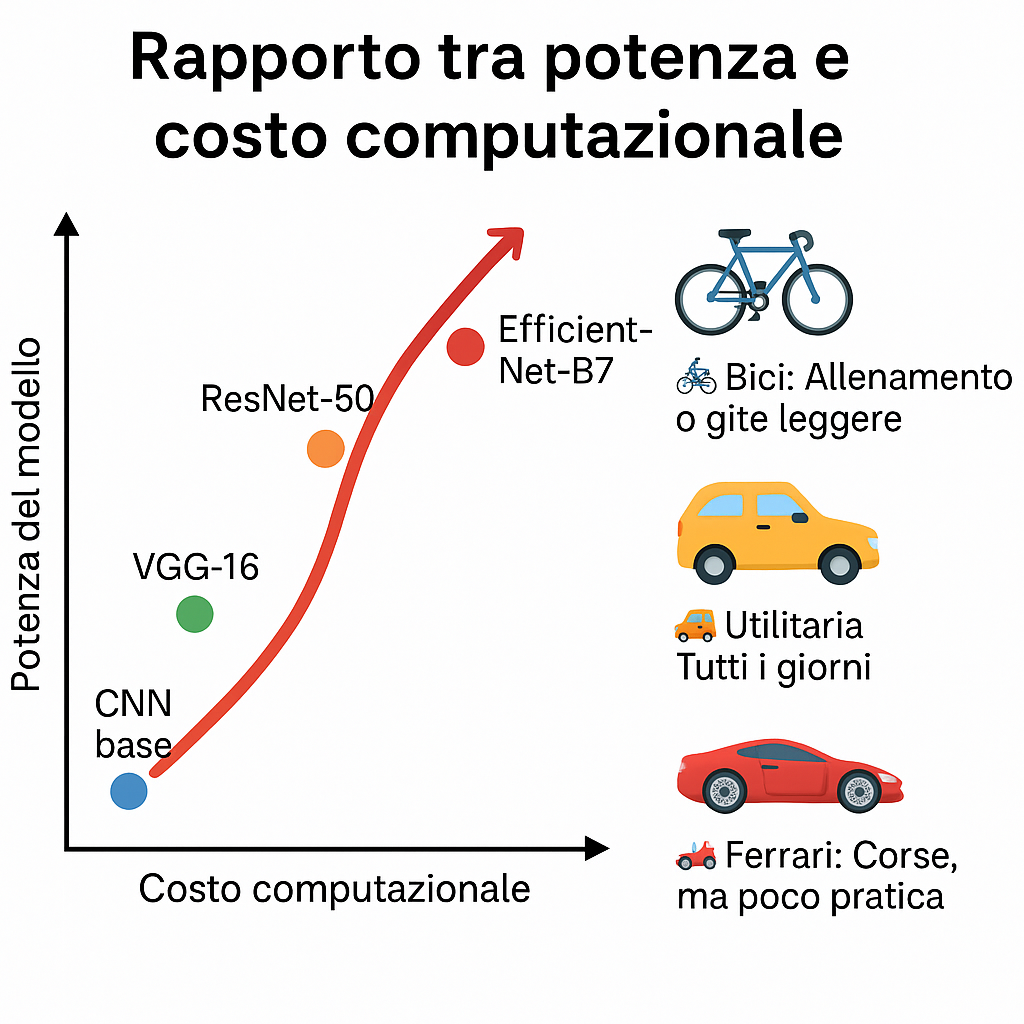

---

## 🔌 1. **Consumo energetico ed emissioni CO₂**

* Allenare un modello grande, come GPT‑3 (175 miliardi di parametri), può consumare oltre **1.287 MWh** e emettere circa **502 tonnellate di CO₂**, equivalenti alla guida di 123 auto per un anno ([fr.wikipedia.org][1], [news.climate.columbia.edu][2]).

* In generale, il training di un singolo grande modello di deep learning può generare **tra 0,5 e 1 tonnellata di CO₂**, a seconda di dimensioni e infrastruttura .

* L’**uso (inference)** spesso consuma più energia del training: circa il **60 %** dell’energia complessiva viene speso per rispondere a richieste ≈ ([news.climate.columbia.edu][2]).

---

## 💧 2. **Consumo di acqua**

* I data center usano tonnellate di acqua per rinfrescare i server: il training di GPT‑3 ha consumato ca. **700.000 litri d’acqua** ([en.wikipedia.org][3]).

* In futuro, l’IA potrebbe richiedere fino a **4,2–6,6 miliardi di m³ d’acqua** all’anno (più della Danimarca) entro il 2027 .

---

## 🌍 3. **Impatto sull’infrastruttura elettrica**

* L’uso di AI può causare **picchi istantanei nell’uso di energia** nei data center, che rischiano di destabilizzare le reti elettriche ([ft.com][4]).

* Previsioni della IEA dicono che i data center potrebbero consumare fino a **945 TWh entro il 2030**, superando l’intero consumo energetico di Paesi come il Giappone ([ft.com][4]).

---

## ⚖️ 4. **Il bilancio energetico dell’IA**

Pur essendo energivora, l’IA può **favorire soluzioni meno impattanti**:

* Aiuta a ottimizzare reti elettriche, pianificazione agricola, trasporti, risparmiando fino a **5,4 miliardi di tonnellate di CO₂ entro il 2035** secondo la Banca Mondiale .

Tuttavia, bisogna fare attenzione al **Jevons Paradox**: una tecnologia più efficiente può aumentare l’uso totale (qui l’AI) e quindi l’impatto complessivo ([en.wikipedia.org][3]).

---

## 🧑‍🏫 Spunti per la classe

1. **Misura ambientale reale:** tradiamo l’idea di IA “pulita”; ha costi energetici e idrici concreti.
2. **Efficienza vs impatto:** modelli più piccoli come BLOOM (176B parametri) hanno pesi ambientali significativamente più leggeri (25 t CO₂) rispetto a GPT‑3 ([arxiv.org][5]).
3. **Scelte responsabili:** anche scolasticamente, possiamo preferire modelli più “leggeri” o utilizzare **data center verdi** (energia pulita, raffreddamento naturale).
4. **Consapevolezza delle infrastrutture:** sapere che il training non è solo un calcolo, ma un fenomeno fisico (energia, rete, acqua).

---

### 🔎 In sintesi

L’IA ha un **impatto ambientale reale e crescente**, che richiede:

* Misurazione dell’impronta di CO₂ e acqua ➜ importante nei progetti,
* Scelte consapevoli verso modelli più piccoli ed efficienti,
* Discussione tra gli studenti su sostenibilità e tecnologia.

---

* [ft.com](https://www.ft.com/content/2789d048-7791-4f9a-8dbe-229c45f8083b?utm_source=chatgpt.com)
* [theguardian.com](https://www.theguardian.com/technology/2025/jun/27/trump-tax-bill-ai-climate-emissions?utm_source=chatgpt.com)
* [theverge.com](https://www.theverge.com/news/694475/google-carbon-emissions-ai-environmental-report-2025?utm_source=chatgpt.com)
* [fr.wikipedia.org](https://fr.wikipedia.org/wiki/Impacts_environnementaux_de_l%27intelligence_artificielle?utm_source=chatgpt.com)

[1]: https://fr.wikipedia.org/wiki/Impacts_environnementaux_de_l%27intelligence_artificielle?utm_source=chatgpt.com "Impacts environnementaux de l'intelligence artificielle"
[2]: https://news.climate.columbia.edu/2023/06/09/ais-growing-carbon-footprint/?utm_source=chatgpt.com "AI's Growing Carbon Footprint - State of the Planet"
[3]: https://en.wikipedia.org/wiki/Environmental_impact_of_artificial_intelligence?utm_source=chatgpt.com "Environmental impact of artificial intelligence"
[4]: https://www.ft.com/content/2789d048-7791-4f9a-8dbe-229c45f8083b?utm_source=chatgpt.com "Hitachi Energy says AI power spikes threaten to destabilise global supply"
[5]: https://arxiv.org/abs/2211.02001?utm_source=chatgpt.com "Estimating the Carbon Footprint of BLOOM, a 176B Parameter Language Model"
